# Simulación de escenarios y contraste de hipótesis
> Cuaderno 5 de 5 del TFM

Carga el modelo XGBoost guardado en el cuaderno *Aprendizaje automático*, del conjunto de test (2025) y de las variables `VARIABLES` y `TARGET` . Las modificaciones se definen sobre la intensidad, la ocupación se deriva de ella mediante la elasticidad estimada y el incremento de la franja adyacente mediante la restricción de conservación del volumen.

| Sección | Contenido | Resultado |
|---|---|---|
| 0 | Configuración, carga del modelo y parámetros | — |
| 1 | Parámetros para la definición de los escenarios | β = 1,334 [1,303; 1,365]; RATIO = 1,565 |
| 2 | Definición de los escenarios | Escenario base y siete escenarios (E1.1–E3.2) |
| 3 | Simulaciones y dominio de aplicabilidad | Fuera de dominio: 4,99 % en base (2,82 % en entrenamiento) |
| 4 | Efecto agregado por escenario | — |
| 5 | Contraste de hipótesis H1, H2 y H3 | Se sostienen las tres hipótesis |
| 6 | Análisis exploratorios complementarios: tipologías y niveles de carga | Secundarias y principales, las más sensibles |
| 6 | Apéndice I: Sensibilidad a β por escenario, tipología y estadístico | Conclusiones cualitativas sin cambios |
| 7 | Apéndice II: Efecto de excluir los festivos entre semana de los días laborables | Conclusiones sin cambios |



## 0. Configuración

### Librerías, carga del modelo XGBoost y parametrización

In [26]:
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import chi2 as chi2_dist
from docx import Document
from docx.shared import Pt, Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
import holidays

BASE = Path(r'C:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\resultados')
CARPETA_PREPROTRANS = BASE / 'preprocesamiento-transformacion'
CARPETA_ENTRADA     = BASE / 'modelo'
CARPETA_SALIDA      = BASE / 'simulaciones'
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CARPETA_PREPROTRANS / 'dataset_modelo.csv')
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values(['id', 'fecha']).reset_index(drop=True)

VARIABLES = ['intensidad', 'ocupacion', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos',
             'mes_sin', 'mes_cos', 'es_laborable', 'es_verano',
             'es_arterial', 'es_principal', 'es_secundaria']
TARGET = 'carga'
FECHA_CORTE_TEST = '2025-01-01'

df['hora']      = df['fecha'].dt.hour
df['intervalo'] = df['hora'] * 4 + df['fecha'].dt.minute // 15
df['dia']       = df['fecha'].dt.date

train   = df[df['fecha'] <  FECHA_CORTE_TEST].copy()
df_test = df[df['fecha'] >= FECHA_CORTE_TEST].copy().reset_index(drop=True)

modelo_final = joblib.load(CARPETA_ENTRADA / 'modelo_xgb0.pkl')

print('Entorno cargado')
print(f'  Entrenamiento: {len(train):,} registros')
print(f'  Test:          {len(df_test):,} registros  ({df_test.fecha.min()} a {df_test.fecha.max()})')
print(f'  Tipologías:    {sorted(df_test["tipologia"].unique())}')

FRANJA_REDUCCION = [7, 8, 9]    # franja punta      7:00 - 9:45
FRANJA_RECEPTORA = [10, 11]     # franja adyacente 10:00 - 11:45

lab = df_test['es_laborable'] == 1
perfil_punta     = lab & df_test['hora'].isin(FRANJA_REDUCCION)
perfil_receptora = lab & df_test['hora'].isin(FRANJA_RECEPTORA)
perfil_dia       = lab
perfil_franjas   = perfil_punta | perfil_receptora

perfil = df_test[lab].groupby('hora')[['intensidad', 'ocupacion', 'carga']].mean()
print(perfil.loc[5:14].round(1))

Entorno cargado
  Entrenamiento: 840,175 registros
  Test:          416,153 registros  (2025-01-01 00:00:00 a 2025-12-31 23:45:00)
  Tipologías:    ['Arterial', 'Principal', 'Residencial', 'Secundaria']
      intensidad  ocupacion  carga
hora                              
5           96.5        1.0    4.0
6          244.8        1.7    9.1
7          727.4        5.7   27.8
8         1038.5       12.1   45.7
9         1038.6       13.3   48.0
10         912.3       10.0   41.8
11         884.0       10.1   40.6
12         884.0       10.2   40.7
13         884.0        9.6   40.1
14         913.2        9.5   40.9


### Etiquetado

Función para rotular las barras de todas las figuras con la variación relativa y,
cuando procede, la absoluta en puntos porcentuales.

In [27]:
def etiquetar(ax, barras, rel, absol=None, fmt_rel='{:+.2f} %',
              fmt_abs='({:+.2f} pp)', fs=8.5, saltar_cero=True):
    """Rotula cada barra con la variación relativa y, si se pasa, la absoluta."""
    rango = ax.get_ylim()[1] - ax.get_ylim()[0]
    for i, bar in enumerate(barras):
        v = rel[i]
        if saltar_cero and abs(v) < 1e-9:
            continue
        arriba = bar.get_height() >= 0
        off = rango * 0.015
        txt = fmt_rel.format(v)
        if absol is not None:
            txt += '\n' + fmt_abs.format(absol[i])
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (off if arriba else -off), txt,
                ha='center', va='bottom' if arriba else 'top',
                fontsize=fs, fontweight='bold', linespacing=1.3)
    ax.margins(y=0.22)

COLORES_TIP = {'Arterial':'#d62728', 'Principal':'#ff7f0e',
               'Secundaria':'#2ca02c', 'Residencial':'#1f77b4'}
PALETA_ESC  = ['#5a5a5a', '#acd3ee', '#1f77b4', '#b9f6b9', "#5cf35c", '#f9b477', '#ff7f0e']

## 1. Parámetros para la definición de los escenarios

### Elasticidad de la ocupación respecto a la intensidad

Se estima mediante la especificación logarítmica con efecto fijo por sensor e intervalo de
quince minutos, sobre el conjunto de entrenamiento y restringida a las dos franjas modificadas.

In [46]:
d = train[(train['es_laborable'] == 1) &
          (train['hora'].isin(FRANJA_REDUCCION + FRANJA_RECEPTORA))]
n_antes = len(d)
d = d[(d['intensidad'] > 0) & (d['ocupacion'] > 0)].copy()

d['log_I'] = np.log(d['intensidad'])
d['log_O'] = np.log(d['ocupacion'])
d['fe']    = d['id'].astype(str) + '_' + d['intervalo'].astype(str)

m_beta = smf.ols('log_O ~ log_I + C(fe)', data=d).fit(
            cov_type='cluster', cov_kwds={'groups': d['dia']})
BETA_GLOBAL = m_beta.params['log_I']
ic = m_beta.conf_int().loc['log_I']

print(f'BETA global = {BETA_GLOBAL:.3f}   IC95% [{ic[0]:.3f}, {ic[1]:.3f}]')
print(f'Observaciones: {len(d):,}, descartadas por valor cero: {n_antes-len(d):,} '
      f'({100*(n_antes-len(d))/n_antes:.2f} %)')
print(f'Grupos de efecto fijo: {d["fe"].nunique()}')

BETA global = 1.334   IC95% [1.303, 1.365]
Observaciones: 120,171, descartadas por valor cero: 4,854 (3.88 %)
Grupos de efecto fijo: 240


#### Estimación elasticidad diferenciada por tipología viaria

In [29]:
BETAS, filas_beta = {}, []
for tip, g in d.groupby('tipologia'):
    m  = smf.ols('log_O ~ log_I + C(fe)', data=g).fit(
            cov_type='cluster', cov_kwds={'groups': g['dia']})
    b, ci = m.params['log_I'], m.conf_int().loc['log_I']
    BETAS[tip] = b
    filas_beta.append({'Tipología': tip, 'beta': round(b, 3),
                       'IC inf': round(ci[0], 3), 'IC sup': round(ci[1], 3),
                       'n': len(g), 'Ocupación media': round(g['ocupacion'].mean(), 1),
                       'Intensidad media': round(g['intensidad'].mean(), 1)})

tabla_beta = pd.DataFrame(filas_beta).sort_values('beta')
print(tabla_beta.to_string(index=False))
tabla_beta.to_csv(CARPETA_SALIDA / 'elasticidad_por_tipologia.csv', index=False)

  Tipología  beta  IC inf  IC sup     n  Ocupación media  Intensidad media
 Secundaria 1.268   1.206   1.329 30143              7.0             543.4
Residencial 1.285   1.252   1.318 30966             10.9             657.9
   Arterial 1.299   1.264   1.334 28073              6.0             715.3
  Principal 1.534   1.467   1.601 30989             16.0            1886.1


####  Validación de la especificación

Se representa la relación sobre
la que se estima el coeficiente.

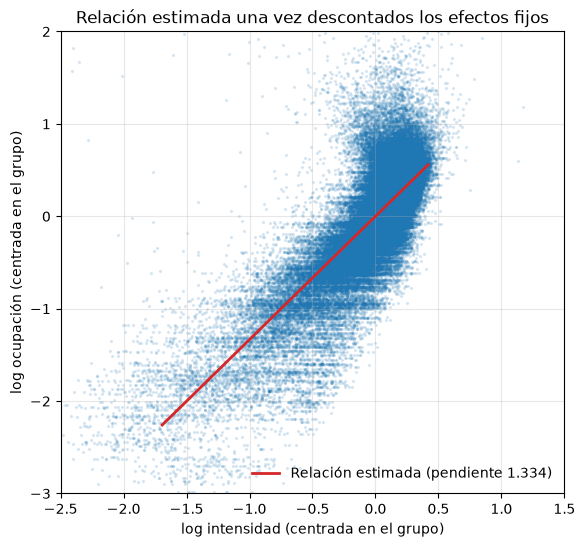

BETA restringido a franja punta: 1.312  IC95% [1.277, 1.347]


In [30]:
d['log_I_w'] = d['log_I'] - d.groupby('fe')['log_I'].transform('mean')
d['log_O_w'] = d['log_O'] - d.groupby('fe')['log_O'].transform('mean')

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(d['log_I_w'], d['log_O_w'], s=2, alpha=0.12, color='#1f77b4')
x = np.linspace(d['log_I_w'].quantile(.005), d['log_I_w'].quantile(.995), 50)
ax.plot(x, BETA_GLOBAL*x, color='#d62728', lw=2,
        label=f'Relación estimada (pendiente {BETA_GLOBAL:.3f})')
ax.set_xlim(-2.5, 1.5); ax.set_ylim(-3, 2)
ax.set_xlabel('log intensidad (centrada en el grupo)')
ax.set_ylabel('log ocupación (centrada en el grupo)')
ax.set_title('Relación estimada una vez descontados los efectos fijos')
ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig(CARPETA_SALIDA / 'validacion_especificacion.png', dpi=150, bbox_inches='tight')
plt.show()

d2 = d[d['hora'].isin(FRANJA_REDUCCION)]
m2 = smf.ols('log_O ~ log_I + C(fe)', data=d2).fit(
        cov_type='cluster', cov_kwds={'groups': d2['dia']})
ic2 = m2.conf_int().loc['log_I']
print(f"BETA restringido a franja punta: {m2.params['log_I']:.3f}  IC95% [{ic2[0]:.3f}, {ic2[1]:.3f}]")


### Restricción de conservación del volumen

El volumen retirado de la franja punta debe reaparecer íntegramente en la adyacente:
δ = ρ · (Σ I punta / Σ I adyacente).

In [31]:
RATIO = (df_test.loc[perfil_punta, 'intensidad'].sum() /
         df_test.loc[perfil_receptora, 'intensidad'].sum())

print(f'Registros   punta: {perfil_punta.sum():,}   adyacente: {perfil_receptora.sum():,}')
print(f'Intervalos  punta: {df_test.loc[perfil_punta,"intervalo"].nunique()}   '
      f'adyacente: {df_test.loc[perfil_receptora,"intervalo"].nunique()}')
print(f'Intensidad media   punta: {df_test.loc[perfil_punta,"intensidad"].mean():.1f}   '
      f'adyacente: {df_test.loc[perfil_receptora,"intensidad"].mean():.1f}')
print(f'\nRATIO = {RATIO:.3f}')
for rho in [0.03, 0.05, 0.075]:
    print(f'  rho = {rho:.1%}  ->  delta adyacente = {rho*RATIO:.1%}')

Registros   punta: 37,200   adyacente: 24,733
Intervalos  punta: 12   adyacente: 8
Intensidad media   punta: 934.7   adyacente: 898.1

RATIO = 1.565
  rho = 3.0%  ->  delta adyacente = 4.7%
  rho = 5.0%  ->  delta adyacente = 7.8%
  rho = 7.5%  ->  delta adyacente = 11.7%


## 2. Definición de los escenarios

Se definen familias, cada una asociada a la hipótesis que contrasta: **E1** (reducción, H1),
**E2** (redistribución, H2) y **E3** (combinación, H3). La composición de los escenarios
combinados es secuencial, primero la reducción y, sobre el volumen remanente, la redistribución.

In [32]:
USAR_BETA_POR_TIPOLOGIA = False
def factores(r, rho):
    return (1 - r) * (1 - rho), rho * (1 - r) * RATIO

def aplicar_escenario(df_base, r, rho):
    e = df_base.copy()
    f_punta, delta = factores(r, rho)
    lab_ = e['es_laborable'] == 1
    mP = lab_ & e['hora'].isin(FRANJA_REDUCCION)
    mA = lab_ & e['hora'].isin(FRANJA_RECEPTORA)
    if USAR_BETA_POR_TIPOLOGIA:
        for tip, b in BETAS.items():
            t = e['tipologia'] == tip
            e.loc[mP & t, 'intensidad'] *= f_punta
            e.loc[mP & t, 'ocupacion']  *= f_punta ** b
            e.loc[mA & t, 'intensidad'] *= (1 + delta)
            e.loc[mA & t, 'ocupacion']  *= (1 + delta) ** b
    else:
        b = BETA_GLOBAL
        e.loc[mP, 'intensidad'] *= f_punta
        e.loc[mP, 'ocupacion']  *= f_punta ** b
        e.loc[mA, 'intensidad'] *= (1 + delta)
        e.loc[mA, 'ocupacion']  *= (1 + delta) ** b
    return e

RHO = 0.05
ESCENARIOS = {
    'E0':   dict(r=0.00, rho=0.000, nombre='Base'),
    'E1.1': dict(r=0.10, rho=0.000, nombre='Reducción moderada'),
    'E1.2': dict(r=0.20, rho=0.000, nombre='Reducción intensiva'),
    'E2.1': dict(r=0.00, rho=0.030, nombre='Redistribución leve'),
    'E2.2': dict(r=0.00, rho=0.050, nombre='Redistribución media'),
    'E2.3': dict(r=0.00, rho=0.075, nombre='Redistribución intensa'),
    'E3.1': dict(r=0.10, rho=0.050, nombre='Reducción moderada y redistribución'),
    'E3.2': dict(r=0.20, rho=0.050, nombre='Reducción intensiva y redistribución'),
}
NOMBRES     = {k: v['nombre'] for k, v in ESCENARIOS.items()}
PRINCIPALES = ['E0', 'E1.1', 'E1.2', 'E2.1','E2.2', 'E3.1', 'E3.2']
ESC_H1      = ['E1.1', 'E1.2']
ESC_H2      = [('E2.1', 0.030), ('E2.2', 0.050), ('E2.3', 0.075)]
ESC_H3     = [('E3.1', 'E1.1', 'E2.2'), ('E3.2', 'E1.2', 'E2.2')]
ESCS        = ['E1.1', 'E1.2', 'E2.1','E2.2', 'E3.1', 'E3.2']

filas = []
for k, v in ESCENARIOS.items():
    if k == 'E0':
        filas.append({'Escenario': k, 'Mecanismo': v['nombre'], 'r': '—', 'rho': '—',
                      'Intensidad punta': '—', 'Intensidad adyacente': '—'}); continue
    f_p, dl = factores(v['r'], v['rho'])
    filas.append({'Escenario': k, 'Mecanismo': v['nombre'],
                  'r': f"{v['r']:.2f}" if v['r'] else '—',
                  'rho': f"{v['rho']:.3f}" if v['rho'] else '—',
                  'Intensidad punta': f'{(f_p-1)*100:+.1f} %',
                  'Intensidad adyacente': f'{dl*100:+.1f} %' if dl > 0 else '—'})
tabla_esc = pd.DataFrame(filas)
print(tabla_esc.to_string(index=False))
tabla_esc.to_csv(CARPETA_SALIDA / 'definicion_escenarios.csv', index=False)

print('\nVariación de la ocupación en punta, por tipología:')
for k, v in ESCENARIOS.items():
    if k == 'E0': continue
    f_p, _ = factores(v['r'], v['rho'])
    det = '  '.join(f'{t}: {(f_p**b-1)*100:+.1f} %' for t, b in BETAS.items())
    print(f'  {k}  ->  {det}')

Escenario                            Mecanismo    r   rho Intensidad punta Intensidad adyacente
       E0                                 Base    —     —                —                    —
     E1.1                   Reducción moderada 0.10     —          -10.0 %                    —
     E1.2                  Reducción intensiva 0.20     —          -20.0 %                    —
     E2.1                  Redistribución leve    — 0.030           -3.0 %               +4.7 %
     E2.2                 Redistribución media    — 0.050           -5.0 %               +7.8 %
     E2.3               Redistribución intensa    — 0.075           -7.5 %              +11.7 %
     E3.1  Reducción moderada y redistribución 0.10 0.050          -14.5 %               +7.0 %
     E3.2 Reducción intensiva y redistribución 0.20 0.050          -24.0 %               +6.3 %

Variación de la ocupación en punta, por tipología:
  E1.1  ->  Arterial: -12.8 %  Principal: -14.9 %  Residencial: -12.7 %  Secundaria:

## 3. Simulaciones y dominio de aplicabilidad

In [33]:
for k, v in ESCENARIOS.items():
    sim = aplicar_escenario(df_test, v['r'], v['rho'])
    df_test[f'carga_{k}'] = modelo_final.predict(sim[VARIABLES])
print('Predicciones calculadas:', [c for c in df_test.columns if c.startswith('carga_')])

# Conservación del volumen
sim_r = aplicar_escenario(df_test, 0.0, RHO)
retirado = df_test.loc[perfil_punta,'intensidad'].sum() - sim_r.loc[perfil_punta,'intensidad'].sum()
anadido  = sim_r.loc[perfil_receptora,'intensidad'].sum() - df_test.loc[perfil_receptora,'intensidad'].sum()
print(f'\nConservación del volumen (E2.2): retirado {retirado:,.0f}, añadido {anadido:,.0f} '
      f' error {100*(anadido-retirado)/retirado:+.4f} %')

# Dominio de aplicabilidad
tope = (train.groupby(['id','hora'])[['intensidad','ocupacion']].quantile([0.01, 0.99]).unstack())
tope.columns = ['i_lo','i_hi','o_lo','o_hi']
tope = tope.reset_index()

def fuera_soporte(dataset, intervalo):
    m = dataset.loc[intervalo, ['id','hora','intensidad','ocupacion']].merge(tope, on=['id','hora'], how='left')
    return ((m['intensidad'] < m['i_lo']) | (m['intensidad'] > m['i_hi']) |(m['ocupacion']  < m['o_lo']) | (m['ocupacion']  > m['o_hi'])).mean()

base_fs = fuera_soporte(df_test, perfil_franjas)
filas = []
for k, v in ESCENARIOS.items():
    if k == 'E0': continue
    f = fuera_soporte(aplicar_escenario(df_test, v['r'], v['rho']), perfil_franjas)
    filas.append({'Escenario': k, 'Mecanismo': v['nombre'],
                  'Base (%)': round(100*base_fs, 2), 'Simulado (%)': round(100*f, 2),
                  'Atribuible (pp)': round(100*(f-base_fs), 2)})
tabla_soporte = pd.DataFrame(filas)
print('\nVERIFICACIÓN DEL DOMINIO DE APLICABILIDAD')
print(tabla_soporte.to_string(index=False))
tabla_soporte.to_csv(CARPETA_SALIDA / 'verificacion_soporte.csv', index=False)

Predicciones calculadas: ['carga_E0', 'carga_E1.1', 'carga_E1.2', 'carga_E2.1', 'carga_E2.2', 'carga_E2.3', 'carga_E3.1', 'carga_E3.2']

Conservación del volumen (E2.2): retirado 1,738,461, añadido 1,738,461  error -0.0000 %

VERIFICACIÓN DEL DOMINIO DE APLICABILIDAD
Escenario                            Mecanismo  Base (%)  Simulado (%)  Atribuible (pp)
     E1.1                   Reducción moderada      4.99          4.48            -0.51
     E1.2                  Reducción intensiva      4.99          4.45            -0.54
     E2.1                  Redistribución leve      4.99          6.06             1.07
     E2.2                 Redistribución media      4.99          7.36             2.37
     E2.3               Redistribución intensa      4.99          9.67             4.68
     E3.1  Reducción moderada y redistribución      4.99          6.69             1.70
     E3.2 Reducción intensiva y redistribución      4.99          6.41             1.42


In [34]:
lab_tr = (train['es_laborable'] == 1) & train['hora'].isin(FRANJA_REDUCCION + FRANJA_RECEPTORA)
print(f'Fuera de dominio en entrenamiento (referencia): {100 * fuera_soporte(train, lab_tr):.2f} %')
print(f'Fuera de dominio en test, escenario base:       {100 * fuera_soporte(df_test, perfil_franjas):.2f} %')

Fuera de dominio en entrenamiento (referencia): 2.82 %
Fuera de dominio en test, escenario base:       4.99 %


## 4. Efecto agregado por escenario


EFECTO EN FRANJA PUNTA LABORABLE
Escenario                            Mecanismo  Carga media (%)  Δ (pp)  Δ relativa (%)
       E0                                 Base        40.099998    0.00        0.000000
     E1.1                   Reducción moderada        36.230000   -3.87       -9.650000
     E1.2                  Reducción intensiva        32.560001   -7.54      -18.790001
     E2.1                  Redistribución leve        38.970001   -1.13       -2.820000
     E2.2                 Redistribución media        38.270000   -1.82       -4.550000
     E2.3               Redistribución intensa        37.330002   -2.77       -6.900000
     E3.1  Reducción moderada y redistribución        34.619999   -5.47      -13.650000
     E3.2 Reducción intensiva y redistribución        30.990000   -9.10      -22.700001

EFECTO EN DÍA COMPLETO LABORABLE
Escenario                            Mecanismo  Carga media (%)  Δ (pp)  Δ relativa (%)
       E0                                 Base      

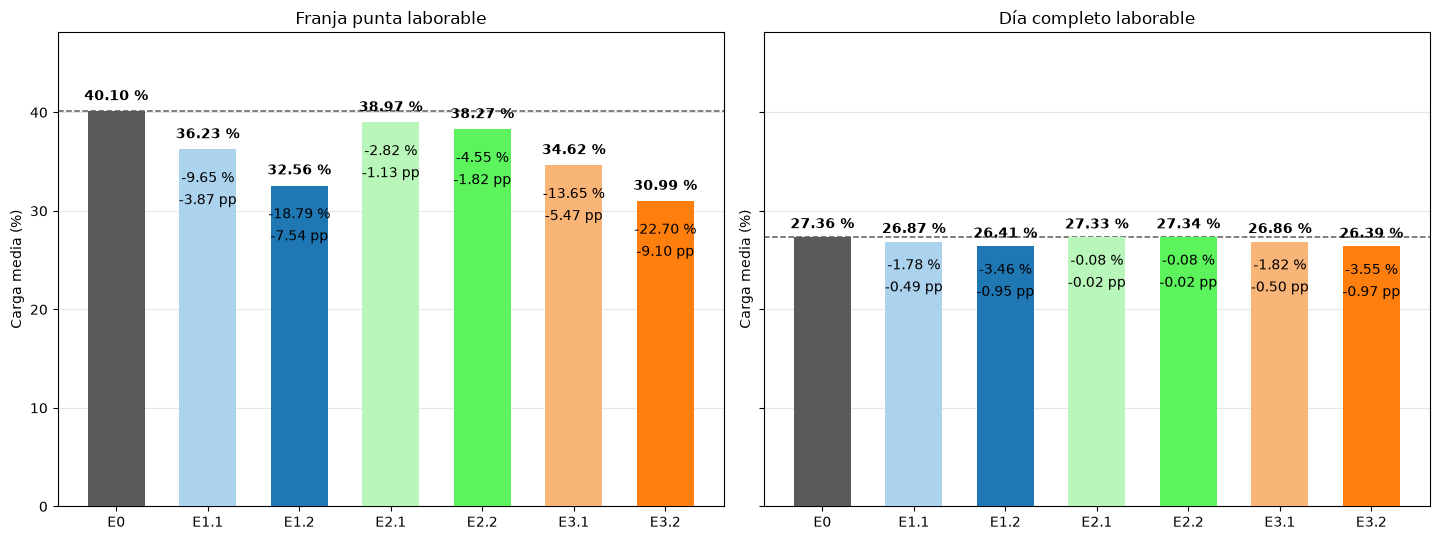

In [35]:
def resumen(perfil, etiqueta):
    base = df_test.loc[perfil, 'carga_E0'].mean()
    filas = []
    for k in ESCENARIOS:
        media = df_test.loc[perfil, f'carga_{k}'].mean()
        filas.append({'Escenario': k, 'Mecanismo': NOMBRES[k],
                      'Carga media (%)': round(media, 2),
                      'Δ (pp)': round(media-base, 2),
                      'Δ relativa (%)': round(100*(media-base)/base, 2)})
    t = pd.DataFrame(filas)
    print(f'\nEFECTO EN {etiqueta.upper()}')
    print(t.to_string(index=False))
    return t

tabla_punta_r = resumen(perfil_punta, 'franja punta laborable')
tabla_dia_r   = resumen(perfil_dia,   'día completo laborable')
tabla_punta_r.to_csv(CARPETA_SALIDA / 'efecto_franja_punta.csv', index=False)
tabla_dia_r.to_csv(CARPETA_SALIDA / 'efecto_dia_completo.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.5), sharey=True)
for ax, (t, tit) in zip(axes, [(tabla_punta_r, 'Franja punta laborable'),
                               (tabla_dia_r,   'Día completo laborable')]):
    sub = t[t['Escenario'].isin(PRINCIPALES)].reset_index(drop=True)
    b = ax.bar(sub['Escenario'], sub['Carga media (%)'], color=PALETA_ESC, width=0.62, zorder=3)
    ax.axhline(sub['Carga media (%)'].iloc[0], color='#5a5a5a', ls='--', lw=1.1)
    rango = sub['Carga media (%)'].max()
    for i, bar in enumerate(b):
        valor = sub['Carga media (%)'][i]
        rel, pp = sub['Δ relativa (%)'][i], sub['Δ (pp)'][i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + rango*0.02,
            f'{valor:.2f} %', ha='center', va='bottom',
            fontsize=10, fontweight='bold', zorder=4)
        if i == 0:
            continue
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - rango*0.04,
            f'{rel:+.2f} %\n{pp:+.2f} pp', ha='center', va='top',
            fontsize=10, linespacing=1.7,
            color='black', zorder=4)
    ax.set_title(tit); ax.set_ylabel('Carga media (%)')
    ax.grid(axis='y', alpha=0.3); ax.margins(y=0.20)
    ax.tick_params(axis='x', labelrotation=0)
plt.tight_layout()
fig.savefig(CARPETA_SALIDA / 'efecto_escenarios.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Contrastes de hipótesis

### Inferencia estadística

Se usa como unidad de remuestreo el día laborable completo, dada la dependencia temporal entre los
registros de una misma jornada.

In [36]:
B_REPLICAS = 1000

def bootstrap_dias(fn, frame, B=B_REPLICAS, semilla=42):
    rng  = np.random.default_rng(semilla)
    dias = frame['dia'].unique()
    idx  = {dd: frame.index[frame['dia'] == dd].to_numpy() for dd in dias}
    out  = np.empty(B)
    for b in range(B):
        sel = rng.choice(dias, size=len(dias), replace=True)
        out[b] = fn(frame.loc[np.concatenate([idx[dd] for dd in sel])])
    return out

def ic95(v):
    return np.percentile(v, [2.5, 97.5])

### H1. Respuesta de la carga viaria a la reducción del tráfico

*La carga viaria de la franja punta matutina disminuye en una proporción distinta a la reducción del tráfico.*

Estadístico: elasticidad de arco ε. H1 se sostiene si el IC 95 % de ε excluye a la unidad en todos los niveles de reducción evaluados.

Nivel r  Carga (%)  Δ (pp)  Δ relativa (%)  Elasticidad  IC inf  IC sup  Deficit (%) Contiene 1
    10%  36.230000   -3.87       -9.650000       0.9632  0.9519  0.9760         3.68         No
    15%  34.450001   -5.65      -14.090000       0.9341  0.9251  0.9442         6.59         No
    20%  32.560001   -7.54      -18.790001       0.9329  0.9234  0.9433         6.71         No
    25%  30.650000   -9.44      -23.549999       0.9336  0.9249  0.9427         6.64         No
    30%  28.680000  -11.42      -28.469999       0.9395  0.9316  0.9481         6.05         No


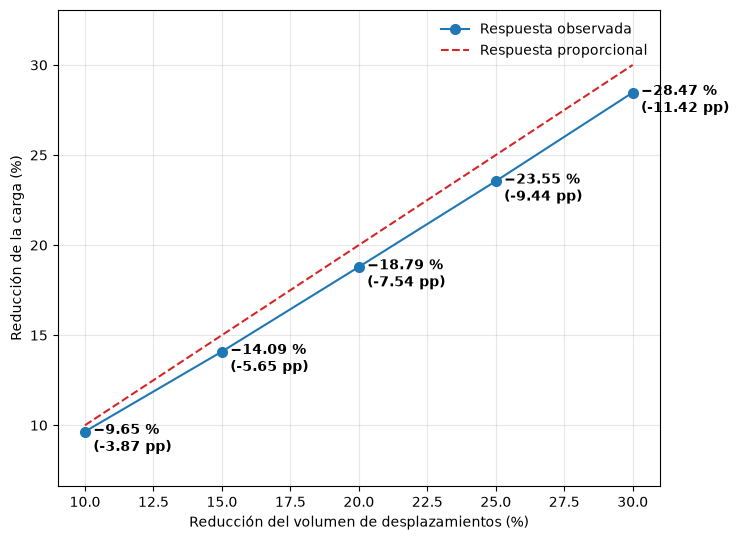

In [47]:
NIVELES = [0.10, 0.15, 0.20, 0.25, 0.30]
for r in NIVELES:
    col = f'carga_r{int(r*100):02d}'
    if col not in df_test.columns:
        df_test[col] = modelo_final.predict(aplicar_escenario(df_test, r, 0.0)[VARIABLES])

punta = df_test[perfil_punta].copy()
BASE_PUNTA = punta['carga_E0'].mean()

def elasticidad(frame, r):
    base  = frame['carga_E0'].mean()
    nuevo = frame[f'carga_r{int(r*100):02d}'].mean()
    return np.log(nuevo / base) / np.log(1 - r)

filas_h1 = []
for r in NIVELES:
    e  = elasticidad(punta, r)
    bs = bootstrap_dias(lambda f, r=r: elasticidad(f, r), punta)
    lo, hi = ic95(bs)
    media = punta[f'carga_r{int(r*100):02d}'].mean()
    filas_h1.append({'Nivel r': f'{r:.0%}', 'r_num': r,
                     'Carga (%)': round(media, 2),
                     'Δ (pp)': round(media - BASE_PUNTA, 2),
                     'Δ relativa (%)': round(100*(media-BASE_PUNTA)/BASE_PUNTA, 2),
                     'Elasticidad': round(e, 4),
                     'IC inf': round(lo, 4), 'IC sup': round(hi, 4),
                     'Deficit (%)': round(100*(1-e), 2),
                     'Contiene 1': 'Sí' if lo <= 1 <= hi else 'No'})
tabla_h1 = pd.DataFrame(filas_h1)
print(tabla_h1.drop(columns='r_num').to_string(index=False))
tabla_h1.to_csv(CARPETA_SALIDA / 'H1_elasticidades.csv', index=False)
contiene_1 = (tabla_h1['Contiene 1'] == 'Sí').all()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
red = -tabla_h1['Δ relativa (%)']
ax.plot(tabla_h1['r_num']*100, red, 'o-', color='#1f77b4', markersize=7, label='Respuesta observada')
ax.plot(tabla_h1['r_num']*100, tabla_h1['r_num']*100, '--', color='#d62728', label='Respuesta proporcional')
for xi, yi, pp in zip(tabla_h1['r_num']*100, red, tabla_h1['Δ (pp)']):
    ax.annotate(f'−{yi:.2f} %\n({pp:+.2f} pp)', (xi, yi), textcoords='offset points',
                xytext=(6, -14), fontsize=10, fontweight='bold', linespacing=1.3)
ax.set_xlabel('Reducción del volumen de desplazamientos (%)')
ax.set_ylabel('Reducción de la carga (%)')
ax.legend(frameon=False); ax.grid(alpha=0.3); ax.margins(y=0.15)

plt.tight_layout()
fig.savefig(CARPETA_SALIDA / 'H1.png', dpi=150, bbox_inches='tight')
plt.show()

### H2. Eficacia de la redistribución temporal del tráfico

*Bajo la conservación del volumen total de tráfico, la redistribución temporal hacia la franja adyacente produce un balance neto favorable, es decir, la carga evitada en la franja punta supera a la añadida en la franja adyacente.*

Estadístico: ratio de transferencia τ, calculada sobre la carga acumulada (suma sobre intervalos y sensores). H2 se sostiene si el límite superior del IC 95 % de τ es inferior a la unidad en los niveles evaluados.

In [38]:
def ratio_transferencia(frame, esc):
    p = frame['hora'].isin(FRANJA_REDUCCION)
    a = frame['hora'].isin(FRANJA_RECEPTORA)
    red = frame.loc[p, f'carga_{esc}'].sum() - frame.loc[p, 'carga_E0'].sum()
    inc = frame.loc[a, f'carga_{esc}'].sum() - frame.loc[a, 'carga_E0'].sum()
    return inc / abs(red)

franjas   = df_test[perfil_franjas].copy()
BASE_ADY  = df_test.loc[perfil_receptora, 'carga_E0'].mean()
print("Carga media franja adyacente")
print(BASE_ADY)

filas_h2 = []
for esc, rho in ESC_H2:
    tau = ratio_transferencia(franjas, esc)
    lo, hi = ic95(bootstrap_dias(lambda f, e=esc: ratio_transferencia(f, e), franjas))
    mp = df_test.loc[perfil_punta,     f'carga_{esc}'].mean()
    ma = df_test.loc[perfil_receptora, f'carga_{esc}'].mean()
    filas_h2.append({'Escenario': esc, 'rho': f'{rho:.1%}',
                     'Punta Δ (pp)': round(mp-BASE_PUNTA, 2),
                     'Punta Δ (%)':  round(100*(mp-BASE_PUNTA)/BASE_PUNTA, 2),
                     'Adyac. Δ (pp)': round(ma-BASE_ADY, 2),
                     'Adyac. Δ (%)':  round(100*(ma-BASE_ADY)/BASE_ADY, 2),
                     'Ratio τ': round(tau, 4),
                     'IC inf': round(lo, 4), 'IC sup': round(hi, 4),
                     'τ < 1': 'Sí' if hi < 1 else 'No'})
tabla_h2 = pd.DataFrame(filas_h2)
print(tabla_h2.to_string(index=False))
tabla_h2.to_csv(CARPETA_SALIDA / 'H2.csv', index=False)

Carga media franja adyacente
40.822758
Escenario  rho  Punta Δ (pp)  Punta Δ (%)  Adyac. Δ (pp)  Adyac. Δ (%)  Ratio τ  IC inf  IC sup τ < 1
     E2.1 3.0%         -1.13        -2.82           1.43          3.49   0.8383  0.8185  0.8575    Sí
     E2.2 5.0%         -1.82        -4.55           2.49          6.11   0.9090  0.8919  0.9257    Sí
     E2.3 7.5%         -2.77        -6.90           3.70          9.06   0.8883  0.8728  0.9028    Sí


#### Descomposición de la ratio de transferencia y corrección por dominio

Esta celda calcula todas las cifras del análisis de H2.

**Situación de partida.** Carga media estimada y observada, intensidad media y número de registros
de la franja punta (7:00-9:45) y de la adyacente (10:00-11:45) en los días laborables de 2025.
El cociente de volumen (RATIO) convierte la fracción retirada de la punta, d, en el aumento
relativo de la adyacente, δ = d · RATIO.

**Métricas por escenario (E2.1, E2.2, E2.3).**
- *τ*: carga acumulada añadida en la adyacente / carga acumulada retirada de la punta.
  τ < 1 indica un balance favorable. IC al 95 % por remuestreo de días (1.000 réplicas).
- *e_P, e_A*: variación relativa de la carga por cada 1 % de variación de la intensidad,
  en la punta y en la adyacente.
- *Fuera de dominio*: registros de la adyacente cuya intensidad u ocupación modificada queda
  fuera del intervalo P1-P99 del entrenamiento por sensor y hora. En ellos el modelo no extrapola.
- *τ corregido*: τ suponiendo que los registros fuera de dominio responden como los de dentro
  (e_A dentro). Es una cota inferior de τ, y la ganancia sin corregir, una cota superior.


In [39]:

P, A = perfil_punta, perfil_receptora

def en_dominio(dataset):
    m = dataset[['id', 'hora', 'intensidad', 'ocupacion']].merge(tope, on=['id', 'hora'], how='left')
    m.index = dataset.index
    return (m['intensidad'].between(m['i_lo'], m['i_hi']) &m['ocupacion'].between(m['o_lo'], m['o_hi']))

def tau_corregido(frame, esc, rho):
    p  = frame['hora'].isin(FRANJA_REDUCCION)
    a  = frame['hora'].isin(FRANJA_RECEPTORA)
    ad = a & frame[f'dentro_{esc}']
    red = frame.loc[p, f'carga_{esc}'].sum() - frame.loc[p, 'carga_E0'].sum()
    eA  = (frame.loc[ad, f'carga_{esc}'].sum() / frame.loc[ad, 'carga_E0'].sum() - 1) / (rho * RATIO)
    inc = eA * rho * RATIO * frame.loc[a, 'carga_E0'].sum()
    return inc / abs(red)

def respuesta(mask, esc, delta):
    return (df_test.loc[mask, f'carga_{esc}'].sum() / df_test.loc[mask, 'carga_E0'].sum() - 1) / delta

for esc, rho in ESC_H2:
    df_test[f'dentro_{esc}'] = en_dominio(aplicar_escenario(df_test, 0.0, rho)).values
franjas_c = df_test[perfil_franjas].copy()

C_P, C_A = df_test.loc[P, 'carga_E0'].mean(), df_test.loc[A, 'carga_E0'].mean()
I_P, I_A = df_test.loc[P, 'intensidad'].mean(), df_test.loc[A, 'intensidad'].mean()
CPV = (C_A / I_A) / (C_P / I_P)

print('Situación de partida')
print(f'   Carga media estimada   punta: {C_P:.2f}    adyacente: {C_A:.2f}')
print(f'   Carga media observada  punta: {df_test.loc[P, "carga"].mean():.2f}    '
      f'adyacente: {df_test.loc[A, "carga"].mean():.2f}')
print(f'   Intensidad media       punta: {I_P:.1f}   adyacente: {I_A:.1f}')
print(f'   RATIO volumen punta/adyacente: {RATIO:.3f}')
print(f'   Carga por vehículo adyacente / punta: {CPV:.3f}  ({100*(CPV-1):+.1f} %)')
print(f'   Registros   punta: {P.sum():,}   adyacente: {A.sum():,}\n')

print('Simulaciones')
filas = []
for esc, rho in ESC_H2:
    delta = rho * RATIO
    dP = df_test.loc[P, f'carga_{esc}'].mean() / C_P - 1
    dA = df_test.loc[A, f'carga_{esc}'].mean() / C_A - 1
    dentro = A & df_test[f'dentro_{esc}']
    fuera  = A & ~df_test[f'dentro_{esc}']

    tau = ratio_transferencia(franjas_c, esc)
    lo, hi = ic95(bootstrap_dias(lambda f, e=esc: ratio_transferencia(f, e), franjas_c))
    tc = tau_corregido(franjas_c, esc, rho)
    lo_c, hi_c = ic95(bootstrap_dias(lambda f, e=esc, r=rho: tau_corregido(f, e, r), franjas_c))

    filas.append({
        'Escenario': esc,
        'rho (%)': 100 * rho,
        'delta ady. (%)': 100 * delta,
        'Punta Δ (pp)': df_test.loc[P, f'carga_{esc}'].mean() - C_P,
        'Punta Δ (%)': 100 * dP,
        'Ady. Δ (pp)': df_test.loc[A, f'carga_{esc}'].mean() - C_A,
        'Ady. Δ (%)': 100 * dA,
        'e_P (punta)': -dP / rho,
        'e_A (ady. total)': dA / delta,
        'τ': tau, 'τ IC inf': lo, 'τ IC sup': hi,
        'Reaparece (%)': 100 * tau,
        'Ganancia neta (%)': 100 * (1 - tau),
        'n ady. fuera': int(fuera.sum()),
        'Fuera de dominio (%)': 100 * fuera.sum() / A.sum(),
        'e_A dentro': respuesta(dentro, esc, delta),
        'e_A fuera': respuesta(fuera, esc, delta),
        'τ corregido': tc, 'τc IC inf': lo_c, 'τc IC sup': hi_c,
        'Ganancia corregida (%)': 100 * (1 - tc),
    })

tabla_h2_completa = pd.DataFrame(filas).set_index('Escenario')
print(tabla_h2_completa.T.round(3).to_string())
tabla_h2_completa.round(4).to_csv(CARPETA_SALIDA / 'H2_tabla_completa.csv')



Situación de partida
   Carga media estimada   punta: 40.10    adyacente: 40.82
   Carga media observada  punta: 40.49    adyacente: 41.17
   Intensidad media       punta: 934.7   adyacente: 898.1
   RATIO volumen punta/adyacente: 1.565
   Carga por vehículo adyacente / punta: 1.060  (+6.0 %)
   Registros   punta: 37,200   adyacente: 24,733

Simulaciones
Escenario                   E2.1      E2.2      E2.3
rho (%)                    3.000     5.000     7.500
delta ady. (%)             4.696     7.826    11.739
Punta Δ (pp)              -1.131    -1.823    -2.768
Punta Δ (%)               -2.820    -4.547    -6.904
Ady. Δ (pp)                1.426     2.493     3.699
Ady. Δ (%)                 3.493     6.106     9.061
e_P (punta)                0.940     0.909     0.921
e_A (ady. total)           0.744     0.780     0.772
τ                          0.838     0.909     0.888
τ IC inf                   0.818     0.892     0.873
τ IC sup                   0.858     0.926     0.903
Reapare

### H3. Anticipación del efecto conjunto a partir de las soluciones individuales

*El efecto de la aplicación conjunta de la reducción y la redistribución temporal del tráfico sobre la carga media de la franja punta es equivalente a la composición de los efectos de cada solución aplicada por separado.*

Estadístico: desviación respecto de la composición I*. Contraste de equivalencia con margen igual al sesgo relativo del modelo en la franja punta. H3 se sostiene si el IC 95 % de I* queda contenido en dicho margen.

In [40]:
MARGEN_H3 = abs(100 * (punta['carga'].mean() - punta['carga_E0'].mean()) / punta['carga'].mean())
print(f'Margen de equivalencia: ±{MARGEN_H3:.2f} %\n')

def interaccion(frame, comb, c1, c2):
    base = frame['carga_E0'].mean()
    return 100 * (frame[f'carga_{comb}'].mean() * base /
                  (frame[f'carga_{c1}'].mean() * frame[f'carga_{c2}'].mean()) - 1)

filas_h3 = []
for comb, c1, c2 in ESC_H3:
    base = punta['carga_E0'].mean()
    obs = 100 * punta[f'carga_{comb}'].mean() / base
    ind = 100 * punta[f'carga_{c1}'].mean() * punta[f'carga_{c2}'].mean() / base**2
    I = interaccion(punta, comb, c1, c2)
    lo, hi = ic95(bootstrap_dias(lambda f, a=comb, b=c1, c=c2: interaccion(f, a, b, c), punta))
    filas_h3.append({
        'Combinado': comb, 'Componentes': f'{c1} + {c2}',
        'Subsistente observada (%)': round(obs, 3),
        'Subsistente composición (%)': round(ind, 3),
        'I* (%)': round(I, 3), 'IC inf': round(lo, 3), 'IC sup': round(hi, 3),
        'IC dentro del margen': 'Sí' if (-MARGEN_H3 <= lo and hi <= MARGEN_H3) else 'No'})

tabla_h3 = pd.DataFrame(filas_h3)
print('H3. DESVIACIÓN RESPECTO DE LA COMPOSICIÓN (franja punta laborable)')
print(tabla_h3.to_string(index=False))
print('\nH3 se sostiene' if (tabla_h3['IC dentro del margen'] == 'Sí').all() else '\nH3 no se sostiene')
tabla_h3.to_csv(CARPETA_SALIDA / 'H3.csv', index=False)

Margen de equivalencia: ±0.98 %

H3. DESVIACIÓN RESPECTO DE LA COMPOSICIÓN (franja punta laborable)
Combinado Componentes  Subsistente observada (%)  Subsistente composición (%)  I* (%)  IC inf  IC sup IC dentro del margen
     E3.1 E1.1 + E2.2                  86.349998                    86.241997   0.125   0.055   0.197                   Sí
     E3.2 E1.2 + E2.2                  77.299004                    77.514999  -0.279  -0.349  -0.204                   Sí

H3 se sostiene


## 6. Análisis exploratorios complementarios

### Análisis tipologías viarias

EFECTO MEDIO POR TIPOLOGÍA (agregado por sensor) — franja punta
               E1.1       E1.2   E2.1   E2.2    E3.1       E3.2
Tipología                                                      
Arterial     -8.923 -16.420000 -2.376 -3.905 -12.171 -19.947001
Principal   -10.226 -21.011999 -2.962 -4.999 -14.985 -25.474001
Residencial  -8.431 -17.214001 -2.569 -4.079 -12.257 -20.909000
Secundaria  -11.227 -20.263000 -3.448 -5.099 -15.170 -24.021999

REDUCCIÓN RELATIVA MEDIA POR TIPOLOGÍA Y SUMA DE RANGOS
              E1.1       E1.2  E2.1  E2.2   E3.1       E3.2  Media  Suma de rangos
Tipología                                                                         
Secundaria  -11.23 -20.260000 -3.45 -5.10 -15.17 -24.020000 -13.20               8
Principal   -10.23 -21.010000 -2.96 -5.00 -14.98 -25.469999 -13.28              10
Residencial  -8.43 -17.209999 -2.57 -4.08 -12.26 -20.910000 -10.91              19
Arterial     -8.92 -16.420000 -2.38 -3.90 -12.17 -19.950001 -10.62              

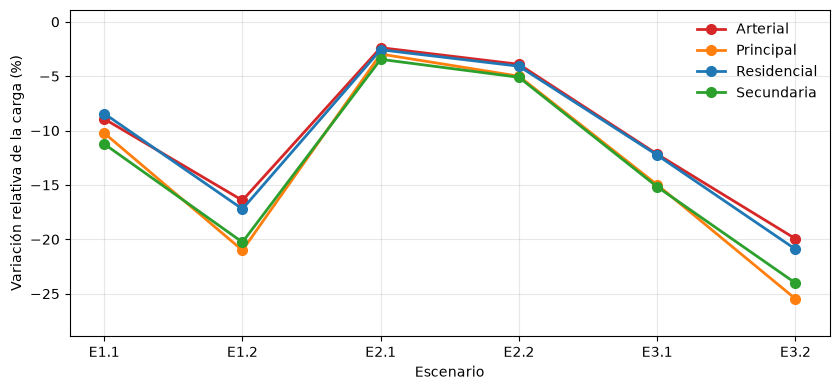

In [41]:
filas_s = []
for (sid, tip), g in df_test[perfil_punta].groupby(['id','tipologia']):
    base_s = g['carga_E0'].mean()
    f = {'Sensor': sid, 'Tipología': tip}
    for e in ESCS:
        f[e] = 100*(g[f'carga_{e}'].mean() - base_s)/base_s
    filas_s.append(f)
efecto_sensor = pd.DataFrame(filas_s)
efecto_sensor.to_csv(CARPETA_SALIDA / 'efecto_por_sensor.csv', index=False)

efecto_tip = efecto_sensor.groupby('Tipología')[ESCS].mean().round(3)
print('EFECTO MEDIO POR TIPOLOGÍA (agregado por sensor) — franja punta')
print(efecto_tip.to_string())
efecto_tip.to_csv(CARPETA_SALIDA / 'efecto_por_tipologia.csv')

# Ordenación descriptiva: rango 1 = mayor reducción en cada escenario
rangos = efecto_tip.rank(axis=0, method='min').astype(int)
tabla_tip = efecto_tip.copy()
tabla_tip['Media'] = efecto_tip.mean(axis=1).round(2)
tabla_tip['Suma de rangos'] = rangos.sum(axis=1)
tabla_tip = tabla_tip.sort_values('Suma de rangos')
print('\nREDUCCIÓN RELATIVA MEDIA POR TIPOLOGÍA Y SUMA DE RANGOS')
print(tabla_tip.round(2).to_string())
tabla_tip.round(3).to_csv(CARPETA_SALIDA / 'tipologias_efecto_y_rangos.csv')

fig, ax = plt.subplots(figsize=(8.5, 4))
for tip in efecto_tip.index:
    ax.plot(ESCS, efecto_tip.loc[tip], marker='o', lw=2, markersize=7,
            color=COLORES_TIP.get(tip), label=tip)    
ax.set_xlabel('Escenario'); ax.set_ylabel('Variación relativa de la carga (%)')
ax.legend(frameon=False); ax.grid(alpha=0.3); ax.margins(y=0.15)


plt.tight_layout()
fig.savefig(CARPETA_SALIDA / 'H5.png', dpi=150, bbox_inches='tight')
plt.show()

### Análisis para distintos niveles de carga


Reducción relativa (%) por decil de carga base
         Carga base   E1.1       E1.2  E2.1  E2.2       E3.1       E3.2
carga_E0                                                               
D1         1.4–12.0  -7.92 -23.190001 -2.68 -1.59 -11.680000 -24.889999
D2        12.0–20.7 -10.52 -20.629999 -1.40 -1.42 -15.460000 -25.030001
D3        20.7–29.5 -15.15 -21.879999 -3.88 -5.48 -18.700001 -25.450001
D4        29.5–37.3 -12.42 -21.120001 -4.08 -6.72 -15.650000 -25.030001
D5        37.3–44.1 -10.73 -20.090000 -3.80 -5.91 -14.810000 -24.059999
D6        44.2–49.5  -9.98 -19.790001 -3.15 -5.10 -14.380000 -23.940001
D7        49.5–53.4  -8.69 -18.520000 -2.53 -4.21 -12.940000 -23.010000
D8        53.4–56.5  -8.06 -16.650000 -2.28 -3.93 -11.830000 -20.540001
D9        56.5–61.2  -8.22 -16.830000 -2.31 -4.01 -12.220000 -20.430000
D10       61.2–91.7  -8.57 -17.660000 -2.43 -4.23 -12.600000 -21.469999
      Media punta (%)  Deciles 3-5 (%)  Deciles 8-10 (%)  Máxima reducción (%) Decil de l

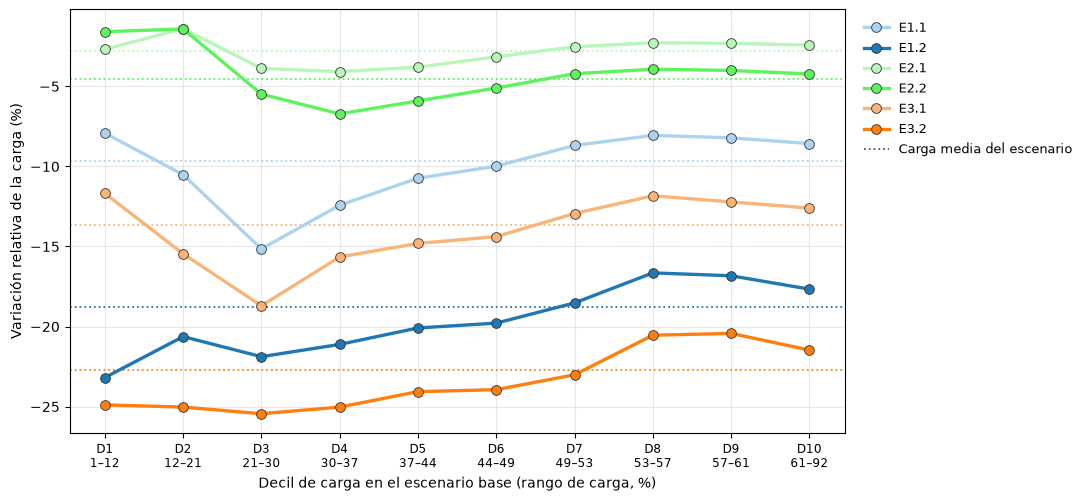

In [42]:
COLOR_ESC = dict(zip(PRINCIPALES, PALETA_ESC))     
bP  = df_test.loc[perfil_punta, 'carga_E0']
dec = pd.qcut(bP, 10, labels=[f'D{i}' for i in range(1, 11)])
rango_dec = bP.groupby(dec, observed=True).agg(['min', 'max'])

red_dec, red_media = {}, {}
for k in ESCS:
    s = df_test.loc[perfil_punta, f'carga_{k}']
    red_media[k] = 100 * (s.mean() / bP.mean() - 1)
    red_dec[k]   = 100 * (s.groupby(dec, observed=True).sum() /
                          bP.groupby(dec, observed=True).sum() - 1)
tabla_dec = pd.DataFrame(red_dec)

resumen_dec = pd.DataFrame({
    'Media punta (%)':        pd.Series(red_media),
    'Deciles 3-5 (%)':        tabla_dec.loc[['D3', 'D4', 'D5']].mean(),
    'Deciles 8-10 (%)':       tabla_dec.loc[['D8', 'D9', 'D10']].mean(),
    'Máxima reducción (%)':   tabla_dec.min(),
    'Decil de la máxima':     tabla_dec.idxmin(),
}).round(2)

print('Reducción relativa (%) por decil de carga base')
print(pd.concat([rango_dec.round(1).astype(str).agg('–'.join, axis=1).rename('Carga base'),
                 tabla_dec.round(2)], axis=1).to_string())
print(resumen_dec.to_string())
tabla_dec.round(3).to_csv(CARPETA_SALIDA / 'reduccion_por_decil.csv')
resumen_dec.to_csv(CARPETA_SALIDA / 'reduccion_por_decil_resumen.csv')

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(1, 11)
for k in ESCS:
    c = COLOR_ESC[k]
    ax.plot(x, tabla_dec[k].values, color=c, lw=2.4, marker='o', markersize=7,
            markeredgecolor='#333333', markeredgewidth=0.6, label=k, zorder=3)
    ax.axhline(red_media[k], color=c, ls=':', lw=1.3, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels([f'D{i}\n{rango_dec.iloc[i-1]["min"]:.0f}–{rango_dec.iloc[i-1]["max"]:.0f}' for i in x],
                   fontsize=8.5)
ax.set_xlabel('Decil de carga en el escenario base (rango de carga, %)')
ax.set_ylabel('Variación relativa de la carga (%)')
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([0], [0], color='#555555', ls=':', lw=1.3))
labels.append('Carga media del escenario')
ax.legend(handles, labels, frameon=False, fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(alpha=0.3)
fig.savefig(CARPETA_SALIDA / 'reduccion_por_decil.png', dpi=150, bbox_inches='tight')
plt.show()

## Apéndice I. Sensibilidad de los resultados a la elasticidad

### Por tipologías

In [43]:

USAR_BETA_POR_TIPOLOGIA = True
for k, v in ESCENARIOS.items():
    if k == 'E0': continue
    df_test[f'bt_{k}'] = modelo_final.predict(aplicar_escenario(df_test, v['r'], v['rho'])[VARIABLES])
USAR_BETA_POR_TIPOLOGIA = False          # se deja activa la β común para el resto del cuaderno

filas_bt = []
for (sid, tip), g in df_test[perfil_punta].groupby(['id', 'tipologia']):
    base_s = g['carga_E0'].mean()
    f = {'Sensor': sid, 'Tipología': tip}
    for e in ESCS:
        f[e] = 100 * (g[f'bt_{e}'].mean() - base_s) / base_s
    filas_bt.append(f)
efecto_tip_bt = pd.DataFrame(filas_bt).groupby('Tipología')[ESCS].mean()

comparacion = pd.DataFrame({
    'Efecto medio (β común)':     efecto_tip.mean(axis=1).round(2),
    'Orden (β común)':            efecto_tip.mean(axis=1).rank().astype(int),
    'Efecto medio (β tipología)': efecto_tip_bt.mean(axis=1).round(2),
    'Orden (β tipología)':        efecto_tip_bt.mean(axis=1).rank().astype(int)})
print(comparacion.to_string())
print('La ordenación ' + ('coincide' if (comparacion['Orden (β común)'] == comparacion['Orden (β tipología)']).all()
                          else 'NO coincide') + ' con ambas parametrizaciones.')
comparacion.to_csv(CARPETA_SALIDA / 'estabilidad_parametrizacion_tipologias.csv')

             Efecto medio (β común)  Orden (β común)  Efecto medio (β tipología)  Orden (β tipología)
Tipología                                                                                            
Arterial                     -10.62                4                      -10.64                    4
Principal                    -13.28                1                      -13.62                    1
Residencial                  -10.91                3                      -10.93                    3
Secundaria                   -13.20                2                      -13.23                    2
La ordenación coincide con ambas parametrizaciones.


### Para todos escenarios y estadísticos

In [44]:
BETA_IC = m_beta.conf_int().loc['log_I'].values
BETAS_SENS = {'β = 1 (proporcional)': 1.0,
              'β IC inferior':        BETA_IC[0],
              'β estimada':           BETA_GLOBAL,
              'β IC superior':        BETA_IC[1]}
ORDEN_B = list(BETAS_SENS)

def aplicar_escenario_beta(df_base, r, rho, beta):
    """Igual que aplicar_escenario, pero con la β indicada (común a todas las tipologías)."""
    e = df_base.copy()
    f_punta, delta = factores(r, rho)
    lab_ = e['es_laborable'] == 1
    mP = lab_ & e['hora'].isin(FRANJA_REDUCCION)
    mA = lab_ & e['hora'].isin(FRANJA_RECEPTORA)
    e.loc[mP, 'intensidad'] *= f_punta
    e.loc[mP, 'ocupacion']  *= f_punta ** beta
    e.loc[mA, 'intensidad'] *= (1 + delta)
    e.loc[mA, 'ocupacion']  *= (1 + delta) ** beta
    return e

ESC_LISTA = [k for k in ESCENARIOS if k != 'E0']
ESC_SENS = {k: (ESCENARIOS[k]['r'], ESCENARIOS[k]['rho']) for k in ESC_LISTA}
ESC_SENS['r30'] = (0.30, 0.0)

# Cálculo para cada β
res = {}
for nombre_b, beta in BETAS_SENS.items():
    tmp = df_test[['dia', 'hora', 'es_laborable', 'carga_E0']].copy()
    for col, (r, rho) in ESC_SENS.items():
        tmp[f'carga_{col}'] = modelo_final.predict(aplicar_escenario_beta(df_test, r, rho, beta)[VARIABLES])
    tmp['carga_r10'], tmp['carga_r20'] = tmp['carga_E1.1'], tmp['carga_E1.2']

    p_tmp, f_tmp = tmp[perfil_punta], tmp[perfil_franjas]
    base_p = p_tmp['carga_E0'].mean()
    d = {}
    for r in [0.10, 0.20, 0.30]:
        e = elasticidad(p_tmp, r)
        lo, hi = ic95(bootstrap_dias(lambda f, r=r: elasticidad(f, r), p_tmp))
        d[f'eps_{r}'] = (e, lo, hi)
    for k in ESC_LISTA:
        d[f'dC_{k}'] = 100 * (p_tmp[f'carga_{k}'].mean() / base_p - 1)
    for esc, rho in ESC_H2:
        d[f'tau_{esc}'] = ratio_transferencia(f_tmp, esc)
    for comb, c1, c2 in ESC_H3:
        d[f'I_{comb}'] = interaccion(p_tmp, comb, c1, c2)
    res[nombre_b] = d

# Tabla
filas_txt = {}
for b in ORDEN_B:
    d = res[b]; col = {'β': round(BETAS_SENS[b], 3)}
    for r in [0.10, 0.20, 0.30]:
        e, lo, hi = d[f'eps_{r}']; col[f'ε r={r:.0%}'] = f'{e:.3f} [{lo:.3f}; {hi:.3f}]'
    for k in ESC_LISTA:        col[f'Δ carga {k} (%)'] = round(d[f'dC_{k}'], 2)
    for esc, _ in ESC_H2:      col[f'τ {esc}'] = round(d[f'tau_{esc}'], 3)
    for comb, _, _ in ESC_H3:  col[f'I* {comb} (%)'] = round(d[f'I_{comb}'], 3)
    filas_txt[b] = col
tabla_sens = pd.DataFrame(filas_txt)
print('\nSENSIBILIDAD A β')
print(tabla_sens.to_string())
tabla_sens.to_csv(CARPETA_SALIDA / 'sensibilidad_beta_completa.csv')


SENSIBILIDAD A β
                  β = 1 (proporcional)         β IC inferior            β estimada         β IC superior
β                                  1.0                 1.303                 1.334                 1.365
ε r=10%           0.873 [0.865; 0.883]  0.962 [0.951; 0.975]  0.963 [0.952; 0.976]  0.965 [0.954; 0.978]
ε r=20%           0.891 [0.883; 0.900]  0.931 [0.922; 0.942]  0.933 [0.923; 0.943]  0.939 [0.929; 0.949]
ε r=30%           0.906 [0.897; 0.915]  0.935 [0.927; 0.944]  0.939 [0.932; 0.948]  0.942 [0.934; 0.951]
Δ carga E1.1 (%)                 -8.79                 -9.64                 -9.65                 -9.67
Δ carga E1.2 (%)            -18.040001                -18.77            -18.790001                 -18.9
Δ carga E2.1 (%)                 -2.75                 -2.82                 -2.82                 -2.82
Δ carga E2.2 (%)                 -4.39                 -4.55                 -4.55                 -4.52
Δ carga E2.3 (%)                 -6.4

## Apéndice II. Efecto de excluir los festivos entre semana de los días laborables

In [45]:
# Festivos nacionales
fest = holidays.Spain(subdiv='MD', years=[2023, 2024, 2025])
# Festivos locales
LOCALES = ['2023-05-15', '2023-11-09', '2024-05-15', '2024-11-09', '2025-05-15', '2025-11-10']
dias_fest = set(pd.to_datetime(list(fest.keys())).date) | set(pd.to_datetime(LOCALES).date)

df_test['es_festivo'] = df_test['dia'].isin(dias_fest)
fest_lab = sorted(df_test.loc[df_test['es_festivo'] & lab, 'dia'].unique())

print(f'Días laborables en 2025: {df_test.loc[lab, "dia"].nunique()}')
print(f'De ellos, festivos entre semana: {len(fest_lab)}')
for d in fest_lab:
    print('  ', d, pd.Timestamp(d).day_name())

def resultados(excluir):
    nf = ~df_test['es_festivo'] if excluir else pd.Series(True, index=df_test.index)
    P, F = perfil_punta & nf, perfil_franjas & nf
    p_, f_ = df_test[P], df_test[F]
    base = p_['carga_E0'].mean()
    out = {'Carga base punta estimada (%)': base,
           'Carga base punta observada (%)': p_['carga'].mean()}
    for r in [0.10, 0.20, 0.30]:
        out[f'ε r = {r:.0%}'] = elasticidad(p_, r)
    for k in [k for k in ESCENARIOS if k != 'E0']:
        out[f'Δ carga {k} (%)'] = 100 * (p_[f'carga_{k}'].mean() / base - 1)
    for esc, _ in ESC_H2:
        out[f'τ {esc}'] = ratio_transferencia(f_, esc)
    for comb, c1, c2 in ESC_H3:
        out[f'I* {comb} (%)'] = interaccion(p_, comb, c1, c2)
    return out

tabla_fest = pd.DataFrame({'Con festivos': resultados(False),
                           'Sin festivos': resultados(True)})
tabla_fest['Diferencia'] = tabla_fest['Sin festivos'] - tabla_fest['Con festivos']
print('\nEFECTO DE EXCLUIR LOS FESTIVOS ENTRE SEMANA')
print(tabla_fest.round(3).to_string())
tabla_fest.round(4).to_csv(CARPETA_SALIDA / 'efecto_festivos.csv')

Días laborables en 2025: 261
De ellos, festivos entre semana: 12
   2025-01-01 Wednesday
   2025-01-06 Monday
   2025-04-17 Thursday
   2025-04-18 Friday
   2025-05-01 Thursday
   2025-05-02 Friday
   2025-05-15 Thursday
   2025-07-25 Friday
   2025-08-15 Friday
   2025-11-10 Monday
   2025-12-08 Monday
   2025-12-25 Thursday

EFECTO DE EXCLUIR LOS FESTIVOS ENTRE SEMANA
                                Con festivos  Sin festivos  Diferencia
Carga base punta estimada (%)         40.097        41.633       1.537
Carga base punta observada (%)        40.492        42.063       1.570
ε r = 10%                              0.963         0.961      -0.002
ε r = 20%                              0.933         0.929      -0.004
ε r = 30%                              0.939         0.938      -0.001
Δ carga E1.1 (%)                      -9.650        -9.630       0.020
Δ carga E1.2 (%)                     -18.792       -18.717       0.075
Δ carga E2.1 (%)                      -2.820        -2.813 